# Komórka 1: Importy i wczytanie danych
W pierwszej kolejności pokazujemy, na czym pracujemy.

In [74]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Wczytujemy dane przygotowane przez skrypty generujące
movies = pd.read_csv('dataset/movies.csv')
print(f"Wczytano {len(movies)} filmów.")
movies.head(10) # Pokazuje pierwsze 3 wiersze tabeli

Wczytano 5000 filmów.


,title,genres,overview,release_date,rating,vote_count
0,Skazani na Shawshank,"18,80",Adaptacja powieści Stephena Kinga. Nominowany ...,1994-09-23,8.713,29314
1,Ojciec chrzestny,"18,80",Akcja filmu toczy się pod koniec II wojny świa...,1972-03-14,8.700,22123
2,Ojciec chrzestny II,"18,80","Ta mistrzowska kontynuacja ""Ojca chrzestnego"" ...",1974-12-20,8.570,13374
3,Lista Schindlera,"18,36,10752",Oskar Schindler jest poważanym niemieckim prze...,1993-12-15,8.566,16888
4,12 gniewnych ludzi,18,Tuż po zakończonej rozprawie sądowej zaczyna s...,1957-04-10,8.548,9561
5,Spirited Away: W krainie Bogów,"16,10751,14","Chihiro jest kapryśną, upartą dziesięcioletnią...",2001-07-20,8.534,17683
6,Mroczny Rycerz,"18,28,80,53","Kontynuacja filmu ""Batman: Początek"", ""Mroczny...",2008-07-16,8.524,34784
7,Żona dla zuchwałych,"35,18,10749","""Żona dla zuchwałych"", dziś już bollywoodzki k...",1995-10-20,8.513,4521
8,Zielona mila,"14,18,80",Paul Edgecomb jest pensjonariuszem domu starcó...,1999-12-10,8.503,18586
9,Parasite,"35,53,18",Żywot rodziny pana Ki-taeka nie należy do najb...,2019-05-30,8.496,19767


# Komórka 2: Przygotowanie cech (Feature Engineering)
Musimy połączyć tekst w jeden ciąg, aby algorytm miał pełny kontekst.

In [66]:
# Łączymy opis i gatunki, wypełniając puste miejsca
movies['combined'] = movies['overview'].fillna(
    '') + " " + movies['genres'].fillna('')

print("Przykład przygotowanego tekstu do analizy:")
print(movies['combined'].iloc[0])

Przykład przygotowanego tekstu do analizy:
Adaptacja powieści Stephena Kinga. Nominowany  Andy Dufresne w 1995 roku do Oscara w 7 kategoriach!  Andy Dufresne jest młodym, obiecującym bankierem. Jego życie zmienia się drastycznie, kiedy zostaje niesłusznie oskarżony o zamordowanie swojej żony i jej kochanka. Skazany na dożywocie, trafia do więzienia Shawshank, gdzie rządy sprawują sadystyczni strażnicy oraz dyrektor hipokryta i oszust. Andy żeby przeżyć lata, jakie przyjdzie mu spędzić w celi, Andy będzie musiał wykazać się sprytem i wolą przetrwania. Przygotowuje również misterny plan zemsty - tak zaskakujący, że zmyli nawet najbliższych współwięźniów. 18,80


# Komórka 3: Wektoryzacja TF-IDF
To jest moment, w którym dzieje się "magia" matematyczna.

In [67]:
# Inicjalizacja wektoryzatora - usuwamy popularne słowa (stop_words)
vectorizer = TfidfVectorizer(stop_words='english')

# Zamiana tekstu na macierz rzadką (sparse matrix)
tfidf_matrix = vectorizer.fit_transform(movies['combined'])

print(f"Kształt macierzy: {tfidf_matrix.shape}")
# Wynik to (liczba_filmów, liczba_unikalnych_słów)

Kształt macierzy: (5000, 49778)


# Komórka 4: Obliczanie Podobieństwa (Cosine Similarity)
Porównujemy filmy ze sobą.

In [68]:
# Obliczamy podobieństwo cosinusowe między wszystkimi filmami
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Pokazujemy fragment macierzy podobieństwa
print("Fragment macierzy podobieństwa (5x5):")
print(cosine_sim[:5, :5])

Fragment macierzy podobieństwa (5x5):
[[1.         0.01294096 0.0046793  0.00622212 0.00750201]
 [0.01294096 1.         0.12835722 0.05955011 0.03189397]
 [0.0046793  0.12835722 1.         0.00288968 0.01347848]
 [0.00622212 0.05955011 0.00288968 1.         0.02134087]
 [0.00750201 0.03189397 0.01347848 0.02134087 1.        ]]


# Komórka 5: Funkcja rekomendująca i test
Praktyczny test silnika.

In [81]:
def get_recommendations(title, n=5):
    # 1. Znajdź indeks filmu o podanym tytule (ignorując wielkość liter)
    try:
        idx = movies[movies['title'].str.contains(title, case=False)].index[0]
    except IndexError:
        return "Nie znaleziono filmu w bazie."

    # 2. Pobierz listę podobieństw dla tego filmu z wcześniej obliczonej macierzy
    sim_scores = list(enumerate(cosine_sim[idx]))

    # 3. Sortuj filmy od najbardziej podobnych, pomijając pierwszy (bo to ten sam film)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]

    # 4. Wyciągnij indeksy i zwróć tytuły
    movie_indices = [i[0] for i in sim_scores]
    return movies[['title', 'genres']].iloc[movie_indices]


# Testujemy działanie dla konkretnego przykładu
print("Rekomendacje dla filmu 'Ojciec Chrzestny':")
get_recommendations('Ojciec Chrzestny')

Rekomendacje dla filmu 'Ojciec Chrzestny':


,title,genres
2,Ojciec chrzestny II,"18,80"
4786,Don Juan DeMarco,"10749,18,35"
18,Grobowiec świetlików,"16,18,10752"
567,Most na rzece Kwai,"18,36,10752"
1092,Dziewczyna w piwnicy,"53,80,10770"


# 6. WIZUALIZACJA: MACIERZ PODOBIEŃSTWA
Heatmapa - "mapa ciepła" relacji:

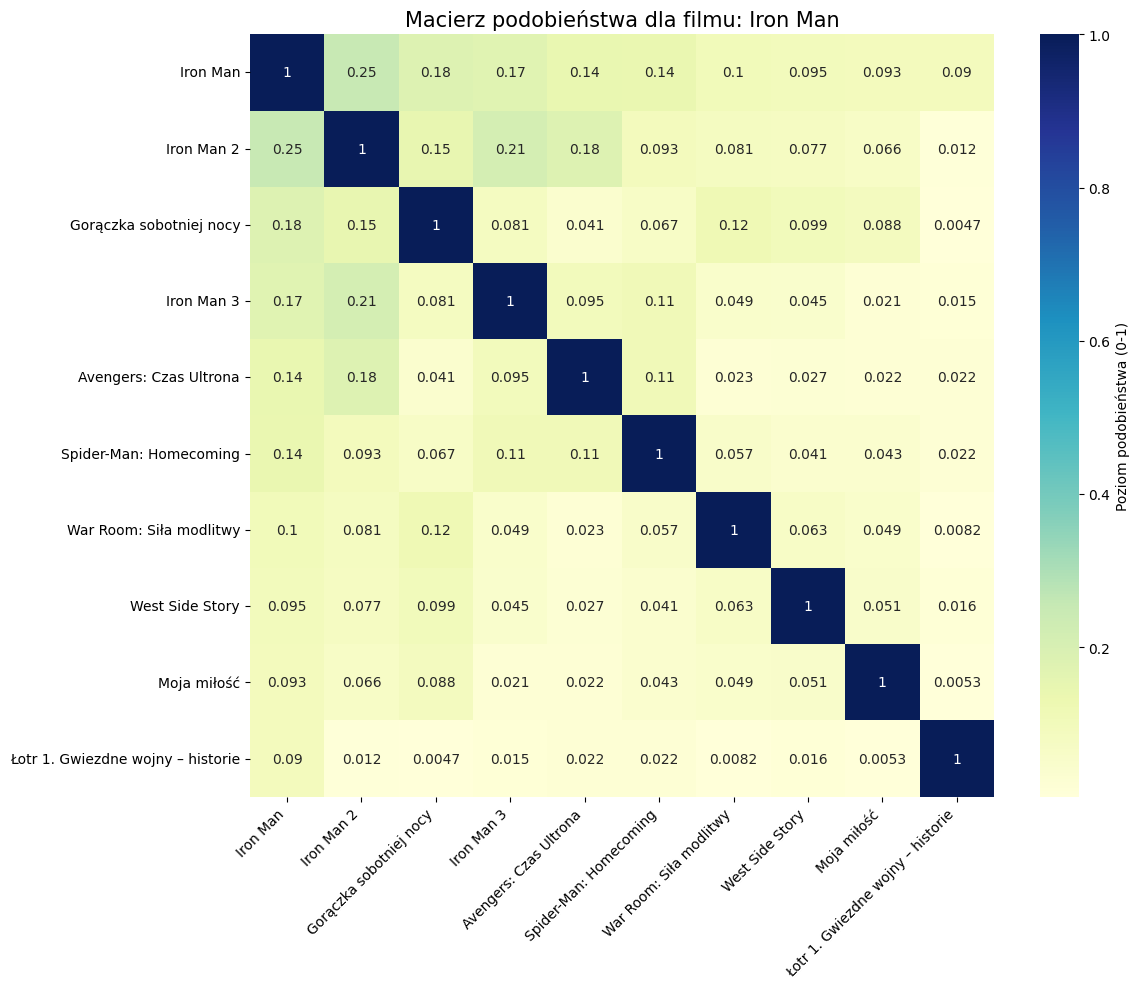

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def plot_similarity_heatmap(title, n=10):
    # 1. Znajdź indeks wpisanego filmu
    try:
        idx = movies[movies['title'].str.contains(title, case=False)].index[0]
    except IndexError:
        print(f"Nie znaleziono filmu: {title}")
        return

    # 2. Pobierz indeksy n najbardziej podobnych filmów
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[:n]
    indices = [i[0] for i in sim_scores]

    # 3. Wyciągnij fragment macierzy podobieństwa tylko dla tych filmów
    # To pokaże jak bardzo filmy polecane są podobne też do siebie nawzajem
    sub_matrix = cosine_sim[np.ix_(indices, indices)]
    labels = movies['title'].iloc[indices].values

    # 4. Rysowanie
    plt.figure(figsize=(12, 10))
    sns.heatmap(sub_matrix, annot=True, xticklabels=labels, yticklabels=labels,
                cmap='YlGnBu', cbar_kws={'label': 'Poziom podobieństwa (0-1)'})

    plt.title(
        f"Macierz podobieństwa dla filmu: {movies.iloc[idx]['title']}", fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# TEST: Wpisz dowolny tytuł
plot_similarity_heatmap('Iron Man')

In [1]:
def show_top_keywords(title, n_terms=10):
    # 1. Znajdź indeks filmu
    try:
        idx = movies[movies['title'].str.contains(title, case=False)].index[0]
    except IndexError:
        print("Nie znaleziono filmu.")
        return

    # 2. Pobierz wektor TF-IDF dla tego konkretnego filmu
    feature_names = vectorizer.get_feature_names_out()
    movie_vector = tfidf_matrix[idx].toarray().flatten()

    # 3. Pobierz indeksy słów z najwyższymi wagami
    top_ids = movie_vector.argsort()[-n_terms:][::-1]

    # 4. Wyświetl wyniki
    print(f"Najważniejsze słowa dla filmu: {movies.iloc[idx]['title']}")
    print("-" * 30)
    for i in top_ids:
        score = movie_vector[i]
        if score > 0:
            print(f"{feature_names[i]:<15} | waga: {score:.4f}")


# TEST: Zobaczmy co 'rozumie' algorytm z filmu Ojciec chrzestny
show_top_keywords('Iran Man')

NameError: name 'movies' is not defined